In [1]:
import numpy as np 
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vivekkapri/internship-company-india/cleaned_internship_companies_INDIA.csv


# LOADING OF DATASET

In [2]:
df=pd.read_csv("/kaggle/input/datasets/vivekkapri/internship-company-india/cleaned_internship_companies_INDIA.csv")

# INFO ON THE DATASET 

In [3]:
df.head()

,Name,Domain,Year_founded,District,State,Country
0,MEDINIS Eduphygital Basaveshwara Engineering C...,Education Industry,2015,Bagalkote,Karnataka,India
1,Agraja Builders & Developers,Construction & Engineering,2008,Dakshina Kannada,Karnataka,India
2,Gully System Pvt Ltd,IT Industry,2021,Bangalore Rural,Karnataka,India
3,JustBreathe - Beinnature Consultancy Pvt Ltd,Manufacturing,2019,Bengaluru Urban,Karnataka,India
4,Creo IT Private Limited,IT Industry,2010,Shimoga,Karnataka,India


In [4]:
df.shape

(780, 6)

In [5]:
df.columns

Index(['Name', 'Domain', 'Year_founded', 'District', 'State', 'Country'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          780 non-null    object
 1   Domain        780 non-null    object
 2   Year_founded  780 non-null    int64 
 3   District      780 non-null    object
 4   State         773 non-null    object
 5   Country       766 non-null    object
dtypes: int64(1), object(5)
memory usage: 36.7+ KB


**finding null value**

In [7]:
df.isnull().sum()

Name             0
Domain           0
Year_founded     0
District         0
State            7
Country         14
dtype: int64

In [8]:
df["State"].unique()

array(['Karnataka', 'Tamil Nadu', 'Kerala', 'Madhya Pradesh', 'India',
       'Maharashtra', 'Uttar Pradesh', 'Andhra Pradesh', nan, 'Gujarat',
       'Bangladesh', 'United Kingdom', 'Delhi', 'Goa', 'Telangana',
       'United Arab Emirates', 'West Bengal', 'Haryana', 'Chhattisgarh',
       'Rajasthan'], dtype=object)

# BASIC CLEANING 

In [9]:
# Drop all rows where the 'State' and 'Country' columns are NaN
df = df.dropna(subset=['State'])
df = df.dropna(subset=['Country'])

In [10]:
# drop the columns with this value 
df.drop(df[df["State"] == "United Arab Emirates"].index, inplace=True)
df.drop(df[df["State"] == "United Kingdom"].index, inplace=True)
df.drop(df[df["State"] == "India"].index, inplace=True)
df.drop(df[df["State"] == "nan"].index, inplace=True)
df.drop(df[df["Domain"] == "Not Specified"].index, inplace=True)

# EDA

## UNIVARIATE EDA 

A fundamental exploratory data analysis (EDA) is conducted to examine the distribution of companies across key parameters, including **Domain, District, State, and Country.** 


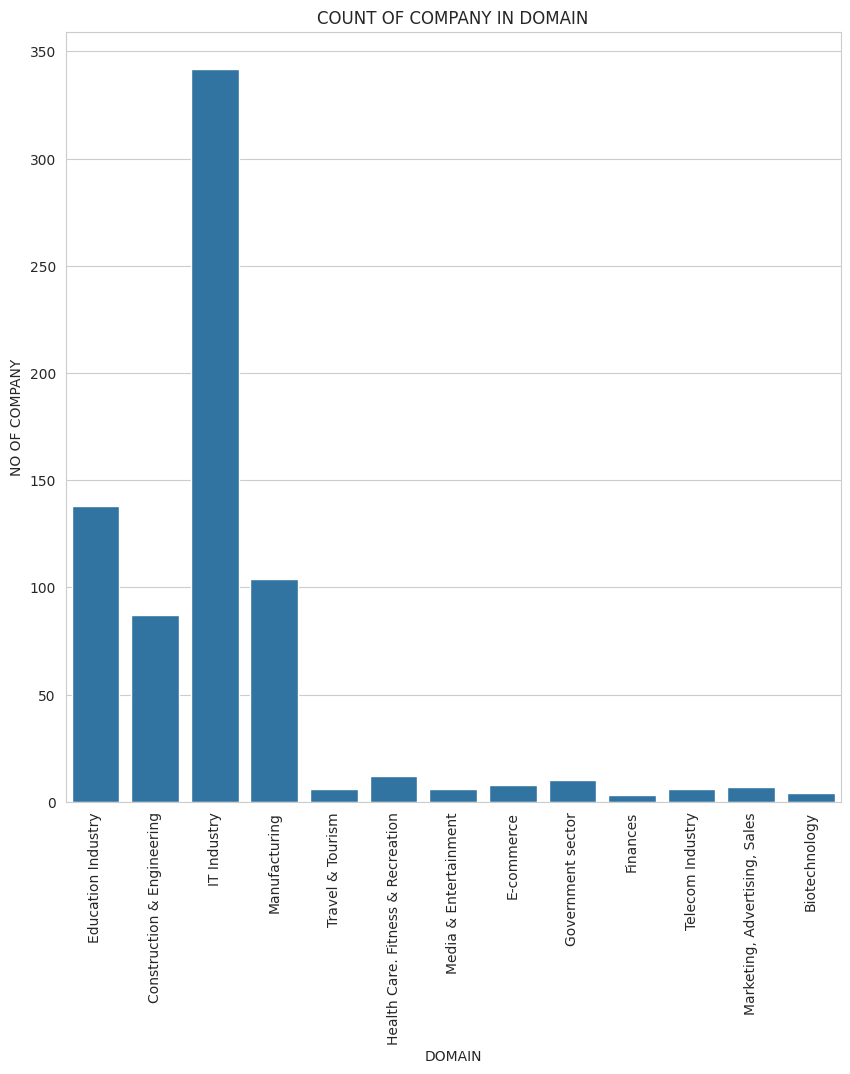

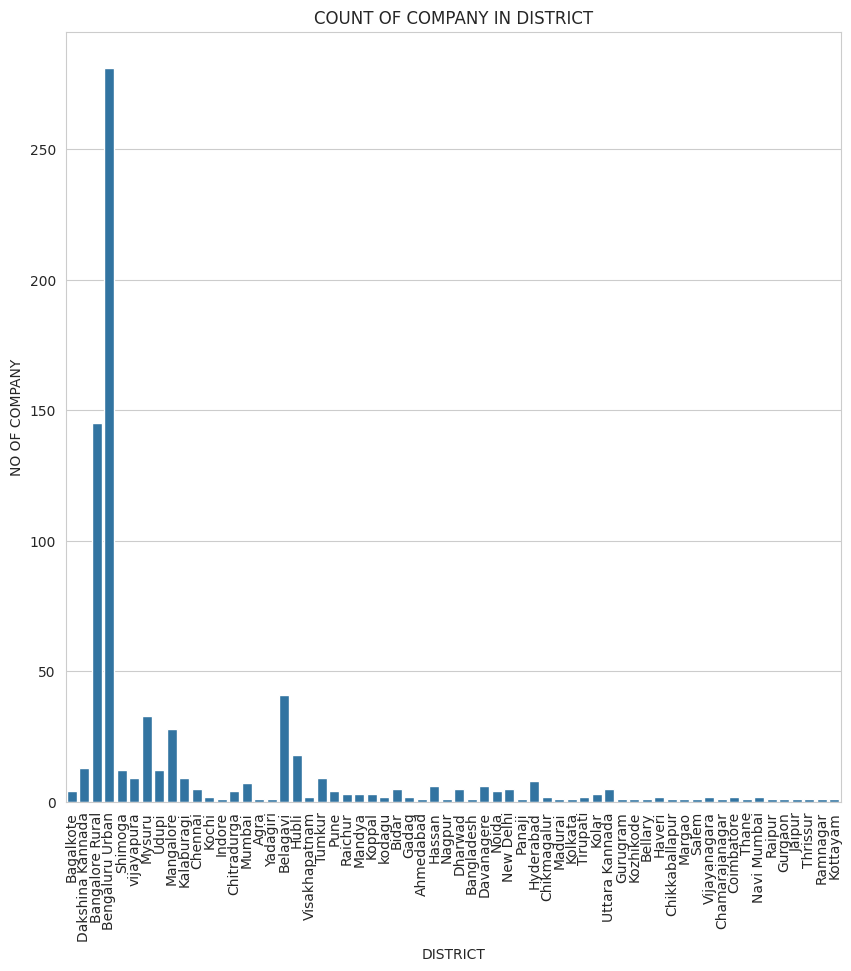

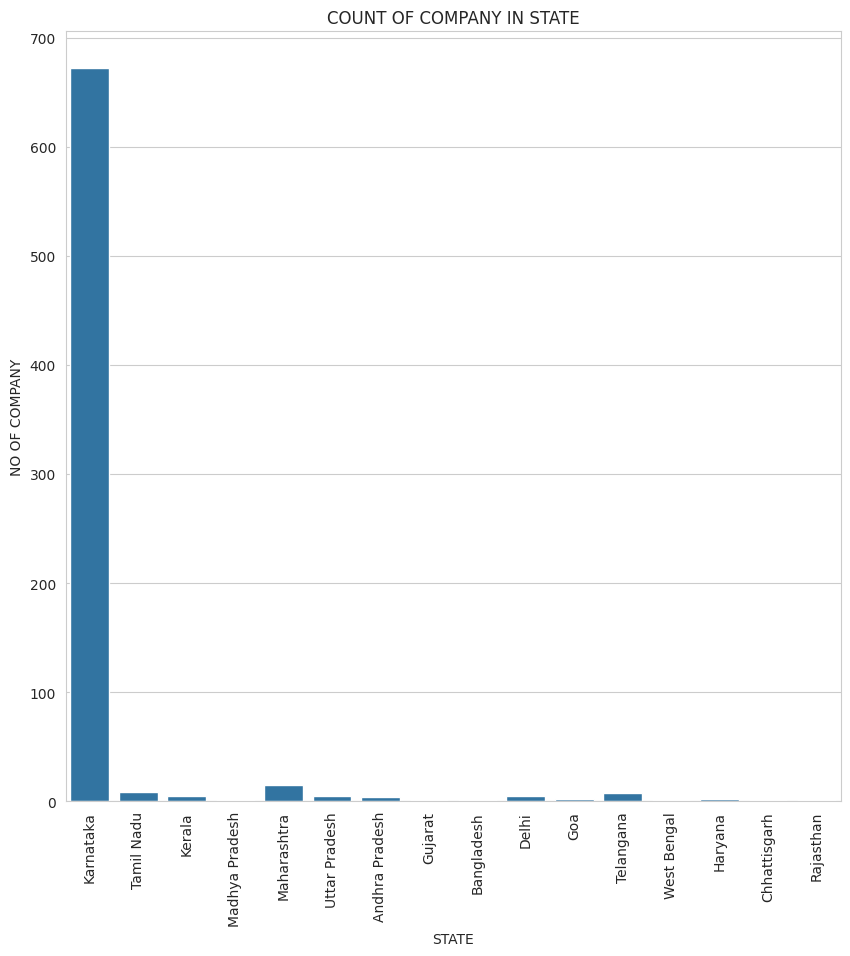

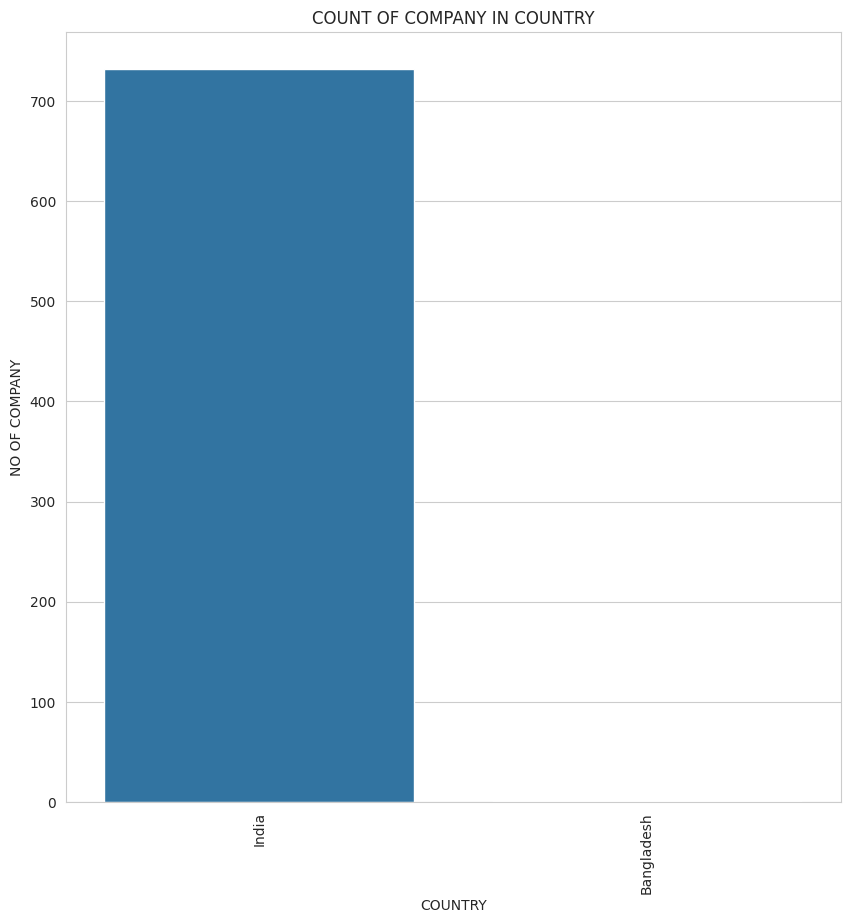

In [11]:
sns.set_style("whitegrid")

columns = ["Domain", "District", "State","Country"]  
for col in columns:
    plt.figure(figsize=(10,10))
    sns.countplot(x=col, data=df)
    plt.title(f"COUNT OF COMPANY IN {col.upper()}")
    plt.xlabel(col.upper())
    plt.ylabel("NO OF COMPANY")
    plt.xticks(rotation=90)
    plt.show()

## BIVARIATE EDA

### Regional Domain Influence Analysis

**The objective of this analysis is to identify the most prominent industry domains and examine their distribution across districts and State to understand regional specialization and industry influence.**


In [12]:
top_domains = df["Domain"].value_counts().head(5).index

top_districts = df["District"].value_counts().head(5).index

top_state =df["State"].value_counts().head(5).index

df_filtered_d= df[
    (df["District"].isin(top_districts)) &
    (df["Domain"].isin(top_domains)) ]
df_filtered_s= df[
    (df["Domain"].isin(top_domains)) &
    (df["State"].isin(top_state)) ]

CR_district= pd.crosstab(df_filtered_d["District"], df_filtered_d["Domain"])
CR_state= pd.crosstab( df_filtered_s["State"],df_filtered_s["Domain"])


In [13]:
CR_district

Domain,Construction & Engineering,Education Industry,Health Care. Fitness & Recreation,IT Industry,Manufacturing
District,,,,,
Bangalore Rural,7,43,2,68,17
Belagavi,5,6,0,20,8
Bengaluru Urban,37,43,3,141,36
Mangalore,5,4,0,15,1
Mysuru,3,4,1,16,7


In [14]:
CR_state

Domain,Construction & Engineering,Education Industry,Health Care. Fitness & Recreation,IT Industry,Manufacturing
State,,,,,
Karnataka,83,126,9,314,97
Maharashtra,2,2,0,7,3
Tamil Nadu,0,2,1,2,2
Telangana,0,2,0,6,0
Uttar Pradesh,0,1,0,3,0


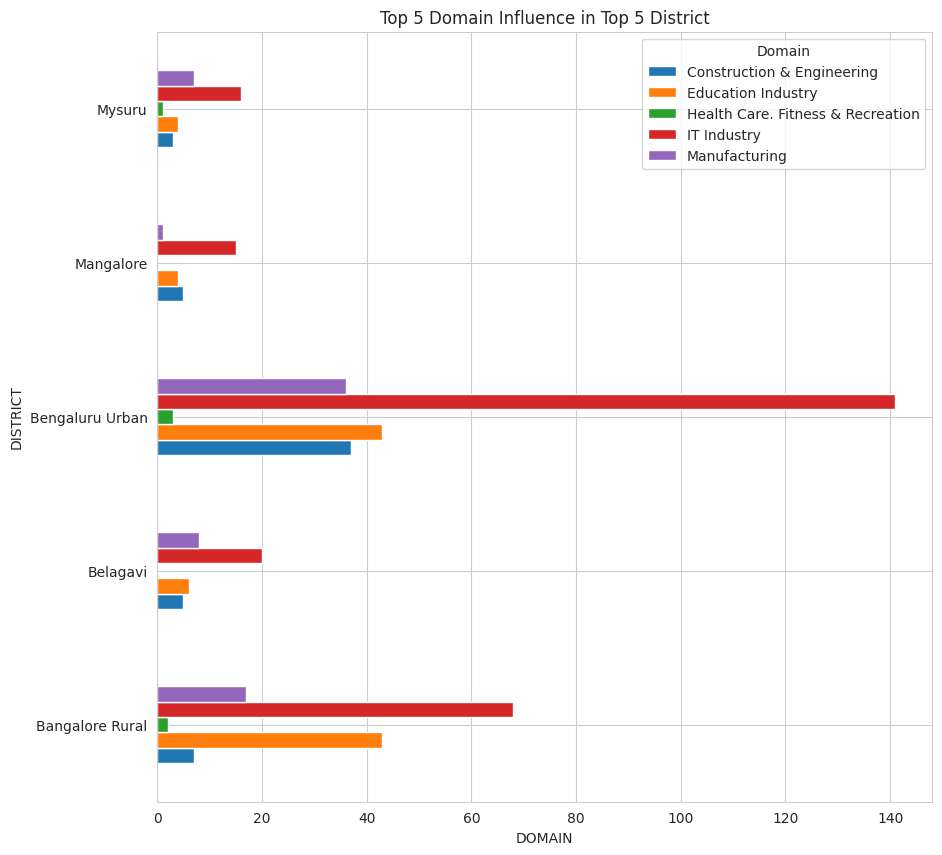

In [15]:
CR_district.plot(kind='barh', figsize=(10,10))
plt.title("Top 5 Domain Influence in Top 5 District")
plt.ylabel("DISTRICT")
plt.xlabel("DOMAIN")
plt.show()




**RESULT** :The analysis indicates that the **IT industry is the most prominent domain** across the dataset. At the district level, **Bengaluru Urban exhibits the highest concentration of IT companies**, highlighting its role as a major technology hub.
 

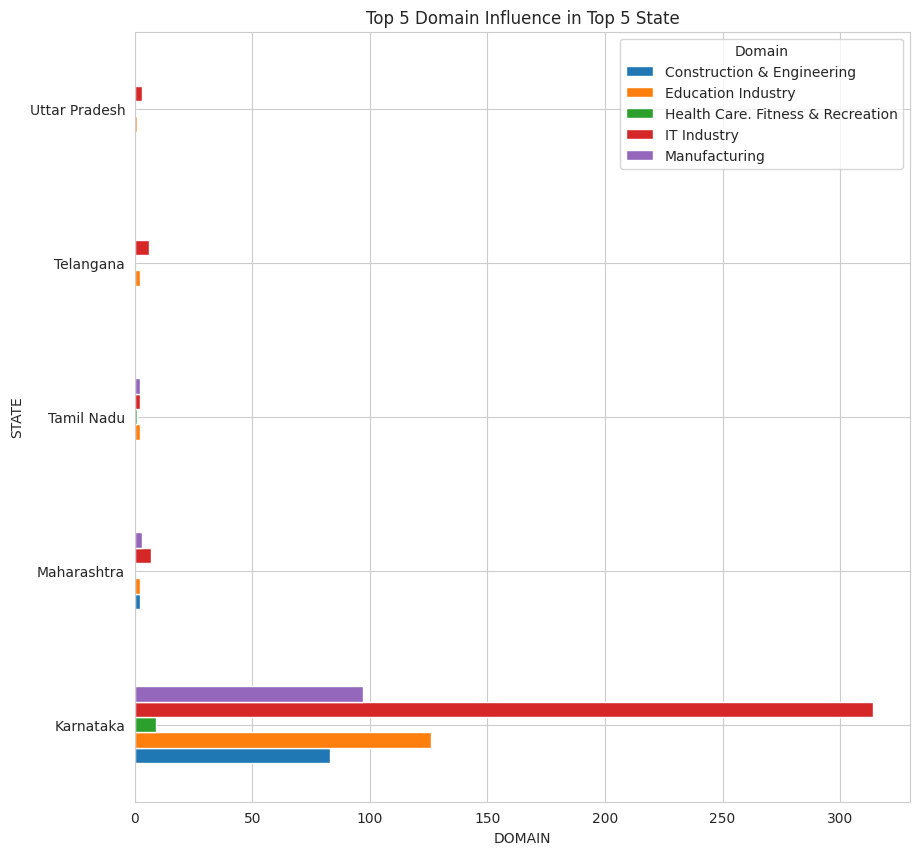

In [16]:
CR_state.plot(kind='barh', figsize=(10,10))
plt.title("Top 5 Domain Influence in Top 5 State")
plt.ylabel("STATE")
plt.xlabel("DOMAIN")
plt.show()

**RESULT** : At the state level, **Karnataka emerges as the leading region in terms of IT industry presence**, indicating a strong regional concentration of technology-driven enterprises.
